In [1]:
# Import Library Dasar

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
# Hubungkan Google Drive ke Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Pastikan file terdeteksi
import os

os.listdir('/content/drive/MyDrive/ML')

['spotify.csv']

In [4]:
# Data Understanding

# 1. Membaca dataset
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/ML/spotify.csv')

In [5]:
# 2. Struktur dataset, Ukuran dataset, Nama kolom
print("===== 5 Data Pertama =====")
display(df.head())

print("\n===== Informasi Dataset =====")
df.info()

print("\n===== Ukuran Dataset =====")
print(df.shape)

print("\n===== Nama Kolom =====")
print(df.columns)

===== 5 Data Pertama =====


,Nama User,Ulasan,Rating,Tanggal,Likes,Versi App
0,Pengguna Google,suka banget sama ni app,5,2025-12-31 17:27:52,0,9.1.6.1145
1,Pengguna Google,bgus,5,2025-12-31 17:25:25,0,9.1.6.1145
2,Pengguna Google,ga bisa denger lagu JKT48 lagi gara² selalu di...,1,2025-12-31 16:39:10,0,9.1.6.1145
3,Pengguna Google,lagunya bagus banget buat ngapa ngapain,5,2025-12-31 16:35:54,0,9.1.6.1145
4,Pengguna Google,"kenapa sih, aku cuman bisa main 5 lagu doang? ...",1,2025-12-31 16:29:15,0,9.1.6.1145



===== Informasi Dataset =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Nama User  100000 non-null  object
 1   Ulasan     100000 non-null  object
 2   Rating     100000 non-null  int64 
 3   Tanggal    100000 non-null  object
 4   Likes      100000 non-null  int64 
 5   Versi App  72298 non-null   object
dtypes: int64(2), object(4)
memory usage: 4.6+ MB

===== Ukuran Dataset =====
(100000, 6)

===== Nama Kolom =====
Index(['Nama User', 'Ulasan', 'Rating', 'Tanggal', 'Likes', 'Versi App'], dtype='object')


In [6]:
# Missing value, Data duplikat, Statistik deskriptif
print("===== Missing Value =====")
print(df.isnull().sum())

print("\n===== Data Duplikat =====")
print(df.duplicated().sum())

print("\n===== Statistik Deskriptif =====")
display(df.describe())

===== Missing Value =====
Nama User        0
Ulasan           0
Rating           0
Tanggal          0
Likes            0
Versi App    27702
dtype: int64

===== Data Duplikat =====
0

===== Statistik Deskriptif =====


,Rating,Likes
count,100000.000000,100000.00000
mean,4.072640,2.70351
std,1.518824,67.86352
min,1.000000,0.00000
25%,4.000000,0.00000
50%,5.000000,0.00000
75%,5.000000,0.00000
max,5.000000,8363.00000


In [7]:
# Exploratory Data Analysis (EDA)

# 1. Membuat label sentimen
def sentiment(rating):
    if rating <= 2:
        return "negatif"
    elif rating == 3:
        return "netral"
    else:
        return "positif"

df["Sentimen"] = df["Rating"].apply(sentiment)
df.head()

# Melihat Jumlah Data Setiap Kelas
print(df["Sentimen"].value_counts())

Sentimen
positif    75670
negatif    19689
netral      4641
Name: count, dtype: int64


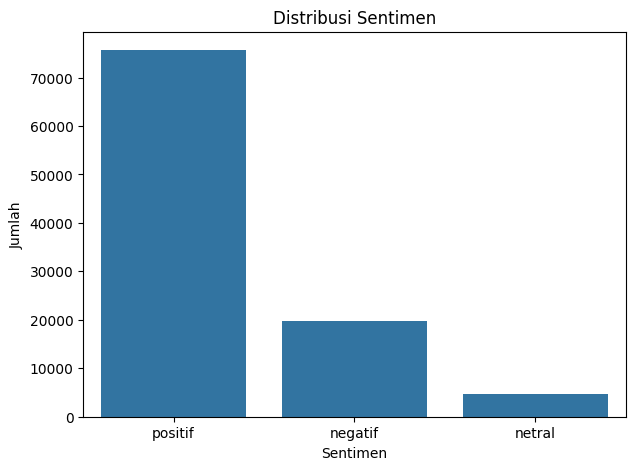

In [8]:
# Visualisasi Distribusi Sentimen
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.countplot(x='Sentimen', data=df)

plt.title("Distribusi Sentimen")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah")

plt.show()

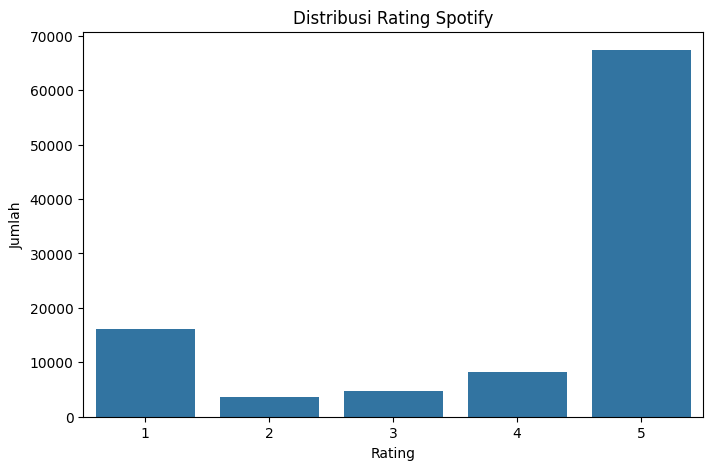

In [9]:
# 2. Distribusi Rating
plt.figure(figsize=(8,5))

sns.countplot(x='Rating', data=df)

plt.title("Distribusi Rating Spotify")
plt.xlabel("Rating")
plt.ylabel("Jumlah")

plt.show()

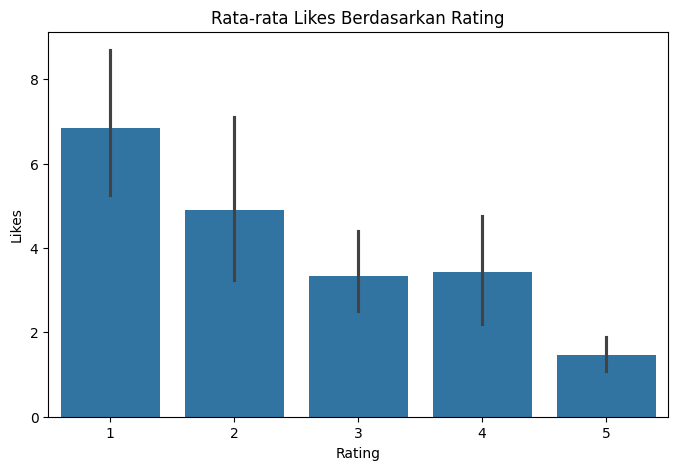

In [10]:
# 3. Rata-rata Likes Berdasarkan Rating
df.groupby('Rating')['Likes'].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    x='Rating',
    y='Likes',
    data=df
)

plt.title("Rata-rata Likes Berdasarkan Rating")
plt.show()

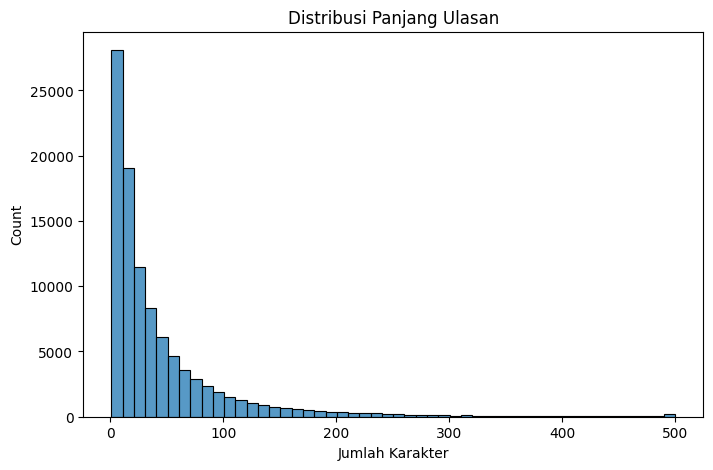

In [11]:
# 4. Panjang Ulasan
df["Panjang_Ulasan"] = df["Ulasan"].astype(str).apply(len)

df["Panjang_Ulasan"].describe()

plt.figure(figsize=(8,5))

sns.histplot(df["Panjang_Ulasan"], bins=50)

plt.title("Distribusi Panjang Ulasan")
plt.xlabel("Jumlah Karakter")
plt.show()

In [12]:
# Data Preparation

# 1. Memilih Kolom yang Dibutuhkan
data = df[['Ulasan', 'Sentimen']].copy()

data.head()


,Ulasan,Sentimen
0,suka banget sama ni app,positif
1,bgus,positif
2,ga bisa denger lagu JKT48 lagi gara² selalu di...,negatif
3,lagunya bagus banget buat ngapa ngapain,positif
4,"kenapa sih, aku cuman bisa main 5 lagu doang? ...",negatif


In [13]:
# 2. Mengecek Missing Value
data.isnull().sum()

data.dropna(inplace=True)

In [14]:
# 3. Import Library yang Dibutuhkan
import re
import string
# 4. Membuat Fungsi Cleaning Text
def clean_text(text):

    # ubah menjadi string
    text = str(text)

    # huruf kecil semua
    text = text.lower()

    # hapus URL
    text = re.sub(r'http\S+|www\S+', '', text)

    # hapus mention dan hashtag
    text = re.sub(r'@\w+|#\w+', '', text)

    # hapus angka
    text = re.sub(r'\d+', '', text)

    # hapus tanda baca
    text = text.translate(str.maketrans('', '', string.punctuation))

    # hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [15]:
# 5. Menerapkan Cleaning
data['clean_text'] = data['Ulasan'].apply(clean_text)

data[['Ulasan','clean_text']].head()

,Ulasan,clean_text
0,suka banget sama ni app,suka banget sama ni app
1,bgus,bgus
2,ga bisa denger lagu JKT48 lagi gara² selalu di...,ga bisa denger lagu jkt lagi gara² selalu di t...
3,lagunya bagus banget buat ngapa ngapain,lagunya bagus banget buat ngapa ngapain
4,"kenapa sih, aku cuman bisa main 5 lagu doang? ...",kenapa sih aku cuman bisa main lagu doang kira...


In [16]:
# 6. Tokenization
import nltk

# Unduh kedua resource yang dibutuhkan
nltk.download('punkt')
nltk.download('punkt_tab')  # <--- Tambahkan baris ini

from nltk.tokenize import word_tokenize

# Jalankan tokenisasi seperti biasa
data['tokens'] = data['clean_text'].apply(word_tokenize)

data[['clean_text','tokens']].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,clean_text,tokens
0,suka banget sama ni app,"[suka, banget, sama, ni, app]"
1,bgus,[bgus]
2,ga bisa denger lagu jkt lagi gara² selalu di t...,"[ga, bisa, denger, lagu, jkt, lagi, gara², sel..."
3,lagunya bagus banget buat ngapa ngapain,"[lagunya, bagus, banget, buat, ngapa, ngapain]"
4,kenapa sih aku cuman bisa main lagu doang kira...,"[kenapa, sih, aku, cuman, bisa, main, lagu, do..."


In [17]:
# 7. Stopword Removal Bahasa Indonesia
# Install Sastrawi
!pip install Sastrawi

# Import library
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Membuat daftar stopword bahasa Indonesia
factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())

# Menghapus stopword
data['stopwords_removed'] = data['tokens'].apply(
    lambda x: [word for word in x if word not in stopwords]
)

# Menggabungkan token menjadi teks akhir
data['processed_text'] = data['stopwords_removed'].apply(
    lambda x: ' '.join(x)
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.8 MB/s eta 0:00:00


In [18]:
# 8. Melihat Hasil Preprocessing
data[['Ulasan',
      'clean_text',
      'tokens',
      'stopwords_removed',
      'processed_text']].head()

,Ulasan,clean_text,tokens,stopwords_removed,processed_text
0,suka banget sama ni app,suka banget sama ni app,"[suka, banget, sama, ni, app]","[suka, banget, sama, ni, app]",suka banget sama ni app
1,bgus,bgus,[bgus],[bgus],bgus
2,ga bisa denger lagu JKT48 lagi gara² selalu di...,ga bisa denger lagu jkt lagi gara² selalu di t...,"[ga, bisa, denger, lagu, jkt, lagi, gara², sel...","[ga, denger, lagu, jkt, gara², selalu, tanya, ...",ga denger lagu jkt gara² selalu tanya mau prem...
3,lagunya bagus banget buat ngapa ngapain,lagunya bagus banget buat ngapa ngapain,"[lagunya, bagus, banget, buat, ngapa, ngapain]","[lagunya, bagus, banget, buat, ngapa, ngapain]",lagunya bagus banget buat ngapa ngapain
4,"kenapa sih, aku cuman bisa main 5 lagu doang? ...",kenapa sih aku cuman bisa main lagu doang kira...,"[kenapa, sih, aku, cuman, bisa, main, lagu, do...","[sih, aku, cuman, main, lagu, doang, kirain, g...",sih aku cuman main lagu doang kirain gratis gk...


In [19]:
# 9. Train-test split
X = data['processed_text']
y = data['Sentimen']

#import
from sklearn.model_selection import train_test_split
#pembagian data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah data training :", X_train.shape)
print("Jumlah data testing :", X_test.shape)



Jumlah data training : (80000,)
Jumlah data testing : (20000,)


In [20]:
# 10. TF-IDF Vectorization

#import
from sklearn.feature_extraction.text import TfidfVectorizer
#buat object
tfidf = TfidfVectorizer()
#transform data
X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Shape data training:", X_train_tfidf.shape)
print("Shape data testing :", X_test_tfidf.shape)

Shape data training: (80000, 29688)
Shape data testing : (20000, 29688)


In [21]:
# Modeling 1

# 1. Logistic Regression
#
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Accuracy Logistic Regression :", accuracy_lr)


Accuracy Logistic Regression : 0.8779


In [26]:
# 2. Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

     negatif       0.75      0.76      0.75      3938
      netral       0.22      0.01      0.02       928
     positif       0.91      0.96      0.94     15134

    accuracy                           0.88     20000
   macro avg       0.63      0.58      0.57     20000
weighted avg       0.85      0.88      0.86     20000



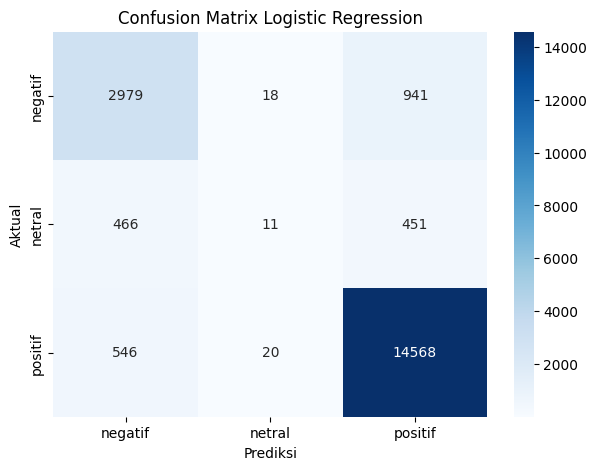

In [27]:
# 3. Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['negatif','netral','positif'],
    yticklabels=['negatif','netral','positif']
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix Logistic Regression")

plt.show()

In [28]:
# Modeling 2

#Support Vector Machine (SVM)

# Import library
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    random_state=42
)

# Melatih model
svm_model.fit(X_train_tfidf, y_train)

# Melakukan prediksi
y_pred_svm = svm_model.predict(X_test_tfidf)

# Menghitung akurasi
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("Accuracy SVM :", accuracy_svm)

Accuracy SVM : 0.8734


In [30]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

     negatif       0.73      0.76      0.74      3938
      netral       0.20      0.02      0.04       928
     positif       0.91      0.96      0.93     15134

    accuracy                           0.87     20000
   macro avg       0.62      0.58      0.57     20000
weighted avg       0.84      0.87      0.86     20000



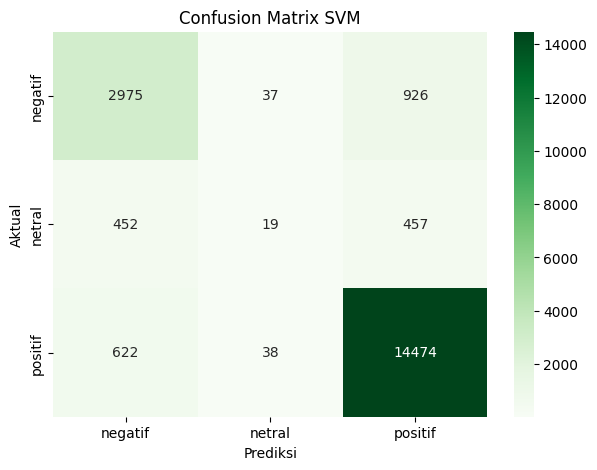

In [31]:
# Confusion Matrix SVM
from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['negatif','netral','positif'],
    yticklabels=['negatif','netral','positif']
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix SVM")

plt.show()